In [1]:
# =========================================================
# INFORMER — IMPORTS AND DATA PIPELINE
# =========================================================
# Duplicates the data pipeline from data_utils.ipynb
# since %run chaining across notebooks is unreliable.
# =========================================================

import pandas as pd
import numpy as np
import zipfile
import requests
import io
from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# =========================================================
# DATA PIPELINE (identical to transformers.ipynb)
# =========================================================

def load_electricity_data():
    url = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"
    response = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(response.content))
    file_name = z.namelist()[0]
    df = pd.read_csv(z.open(file_name), sep=";", decimal=",", parse_dates=[0], quotechar='"')
    df.rename(columns={df.columns[0]: "datetime"}, inplace=True)
    df.set_index("datetime", inplace=True)
    return df

def aggregate_data(df):
    df["total_load"] = df.sum(axis=1)
    df_hourly = df["total_load"].resample("H").sum().to_frame()
    return df_hourly

def create_features(df_hourly):
    if isinstance(df_hourly, pd.Series):
        df_hourly = df_hourly.to_frame(name="total_load")
    df_hourly.index = pd.to_datetime(df_hourly.index)
    df_features = df_hourly.copy()
    df_features["hour_of_day"] = df_features.index.hour
    df_features["day_of_week"] = df_features.index.dayofweek
    df_features["is_weekend"] = (df_features["day_of_week"] >= 5).astype(int)
    df_features["month"] = df_features.index.month
    df_features["hour_sin"] = np.sin(2 * np.pi * df_features["hour_of_day"] / 24)
    df_features["hour_cos"] = np.cos(2 * np.pi * df_features["hour_of_day"] / 24)
    df_features["dayofweek_sin"] = np.sin(2 * np.pi * df_features["day_of_week"] / 7)
    df_features["dayofweek_cos"] = np.cos(2 * np.pi * df_features["day_of_week"] / 7)
    df_features["month_sin"] = np.sin(2 * np.pi * (df_features["month"] - 1) / 12)
    df_features["month_cos"] = np.cos(2 * np.pi * (df_features["month"] - 1) / 12)
    return df_features

def split_time_series(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()

def normalize_splits(train_df, val_df, test_df, feature_cols):
    scaler = StandardScaler()
    train_scaled, val_scaled, test_scaled = train_df.copy(), val_df.copy(), test_df.copy()
    train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    val_scaled[feature_cols] = scaler.transform(val_df[feature_cols])
    test_scaled[feature_cols] = scaler.transform(test_df[feature_cols])
    return train_scaled, val_scaled, test_scaled, scaler

def create_sequences(data, input_window=168, forecast_horizon=24):
    feature_cols = ['total_load', 'hour_sin', 'hour_cos',
                    'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos']
    features = data[feature_cols].values
    targets = data['total_load'].values
    X, y = [], []
    for i in range(len(features) - input_window - forecast_horizon + 1):
        X.append(features[i : i + input_window])
        y.append(targets[i + input_window : i + input_window + forecast_horizon])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

# --- Run pipeline ---
df = load_electricity_data()
df_hourly = aggregate_data(df)
df_features = create_features(df_hourly)
train_df, val_df, test_df = split_time_series(df_features)
train_scaled, val_scaled, test_scaled, scaler = normalize_splits(train_df, val_df, test_df, ["total_load"])

train = train_scaled
val = val_scaled
test = test_scaled

X_train, y_train = create_sequences(train)
X_val, y_val = create_sequences(val)
X_test, y_test = create_sequences(test)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: torch.Size([24354, 168, 7]), y_train: torch.Size([24354, 24])
X_val:   torch.Size([5068, 168, 7]),   y_val:   torch.Size([5068, 24])
X_test:  torch.Size([5070, 168, 7]),  y_test:  torch.Size([5070, 24])


/tmp/ipykernel_709/2698822351.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df["total_load"].resample("H").sum().to_frame()


In [3]:
# =========================================================
# INFORMER MODEL ARCHITECTURE
# =========================================================
# The Informer (Zhou et al., 2021) improves on the vanilla
# Transformer for long-sequence time series forecasting.
# Key difference: ProbSparse self-attention, which reduces
# the O(n^2) complexity of full attention to O(n log n)
# by selecting only the most important query-key pairs.
#
# This makes Informer more efficient on long input sequences
# (like our 168-step window) while maintaining or improving
# forecasting quality.
#
# Architecture:
#   Input [batch, 168, 7]
#   → Linear projection to d_model
#   → Positional encoding
#   → Informer encoder with ProbSparse attention
#   → Flatten + MLP output head
#   → Quantile predictions [batch, 24, 3]
# =========================================================

class ProbSparseAttention(nn.Module):
    """
    ProbSparse self-attention mechanism from the Informer paper.
    Instead of computing attention for all queries, it selects
    the top-u queries with the highest "sparsity measurement"
    (KL divergence from uniform distribution), where u = c * ln(L).
    This reduces computation from O(L^2) to O(L * ln(L)).
    """
    def __init__(self, d_model, nhead, factor=5, dropout=0.1):
        super().__init__()
        self.nhead = nhead
        self.d_k = d_model // nhead
        self.factor = factor

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch, seq_len, _ = x.shape

        # Project to Q, K, V and reshape for multi-head
        Q = self.W_q(x).view(batch, seq_len, self.nhead, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch, seq_len, self.nhead, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch, seq_len, self.nhead, self.d_k).transpose(1, 2)

        # Number of top queries to select: u = c * ln(L)
        u = max(1, int(self.factor * math.log(seq_len + 1)))
        u = min(u, seq_len)

        # Sparsity measurement: sample keys and compute approximate attention
        n_sample = max(1, int(math.log(seq_len + 1)))
        n_sample = min(n_sample, seq_len)

        # Random sample of keys for sparsity estimation
        sample_idx = torch.randint(0, seq_len, (n_sample,), device=x.device)
        K_sample = K[:, :, sample_idx, :]

        # Compute Q * K_sample^T to estimate query importance
        qk_sample = torch.matmul(Q, K_sample.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Sparsity measurement: max - mean of each query's attention
        M = qk_sample.max(dim=-1).values - qk_sample.mean(dim=-1)

        # Select top-u queries
        top_u = M.topk(u, dim=-1).indices

        # Gather selected queries
        top_u_expanded = top_u.unsqueeze(-1).expand(-1, -1, -1, self.d_k)
        Q_selected = Q.gather(2, top_u_expanded)

        # Full attention only on selected queries
        attn_scores = torch.matmul(Q_selected, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        attn_output = torch.matmul(attn_weights, V)

        # Fill non-selected positions with mean of V (distilling)
        V_mean = V.mean(dim=2, keepdim=True).expand_as(V)
        full_output = V_mean.clone()
        top_u_out = top_u.unsqueeze(-1).expand(-1, -1, -1, self.d_k)
        full_output.scatter_(2, top_u_out, attn_output)

        # Reshape back
        full_output = full_output.transpose(1, 2).contiguous().view(batch, seq_len, -1)
        return self.out_proj(full_output)


class InformerEncoderLayer(nn.Module):
    """Single Informer encoder layer with ProbSparse attention."""
    def __init__(self, d_model, nhead, dim_feedforward=128, dropout=0.1, factor=5):
        super().__init__()
        self.attention = ProbSparseAttention(d_model, nhead, factor, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Self-attention with residual
        attn_out = self.attention(x)
        x = self.norm1(x + self.dropout(attn_out))
        # Feed-forward with residual
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (same as vanilla Transformer)."""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x


class InformerForecaster(nn.Module):
    """
    Full Informer model for probabilistic electricity load forecasting.
    Uses ProbSparse attention instead of full self-attention.
    Outputs three quantiles (q10, q50, q90) for each forecast step.
    """
    def __init__(self, input_features=7, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, input_window=168,
                 forecast_horizon=24, num_quantiles=3, factor=5):
        super().__init__()
        self.forecast_horizon = forecast_horizon
        self.num_quantiles = num_quantiles

        self.input_projection = nn.Linear(input_features, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len=input_window)

        self.encoder_layers = nn.ModuleList([
            InformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, factor)
            for _ in range(num_layers)
        ])

        self.output_head = nn.Sequential(
            nn.Linear(d_model * input_window, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, forecast_horizon * num_quantiles)
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.positional_encoding(x)
        for layer in self.encoder_layers:
            x = layer(x)
        x = x.reshape(x.size(0), -1)
        x = self.output_head(x)
        x = x.reshape(-1, self.forecast_horizon, self.num_quantiles)
        return x

# --- Quick test ---
informer_test = InformerForecaster().to(device)
test_out = informer_test(torch.randn(2, 168, 7).to(device))
print(f"Informer output shape: {test_out.shape}")  # should be [2, 24, 3]
del informer_test, test_out

Informer output shape: torch.Size([2, 24, 3])


In [4]:
# =========================================================
# TRAIN INFORMER MODEL
# =========================================================
# Same training setup as the vanilla Transformer for a
# fair comparison: quantile loss, Adam optimizer,
# ReduceLROnPlateau scheduler, gradient clipping.
# =========================================================

class QuantileLoss(nn.Module):
    def __init__(self, quantiles=[0.1, 0.5, 0.9]):
        super().__init__()
        self.quantiles = quantiles

    def forward(self, predictions, targets):
        targets = targets.unsqueeze(-1)
        losses = []
        for i, q in enumerate(self.quantiles):
            errors = targets - predictions[:, :, i].unsqueeze(-1)
            loss = torch.max(q * errors, (q - 1) * errors)
            losses.append(loss.mean())
        return sum(losses) / len(losses)


def train_informer(model, train_loader, val_loader, criterion, num_epochs=30, lr=1e-3, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        epoch_train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- Validation ---
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                preds = model(x_batch)
                loss = criterion(preds, y_batch)
                epoch_val_loss += loss.item()

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_informer.pt')

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

    model.load_state_dict(torch.load('best_informer.pt'))
    print(f"\nTraining complete. Best Val Loss: {best_val_loss:.4f}")
    return model, train_losses, val_losses


# --- Train ---
informer_model = InformerForecaster(
    input_features=7, d_model=64, nhead=4, num_layers=2,
    dim_feedforward=128, dropout=0.1, input_window=168,
    forecast_horizon=24, num_quantiles=3, factor=5
).to(device)

criterion_inf = QuantileLoss(quantiles=[0.1, 0.5, 0.9])

informer_model, inf_train_losses, inf_val_losses = train_informer(
    informer_model, train_loader, val_loader, criterion_inf,
    num_epochs=30, lr=1e-3, device=device
)

Epoch 1/30 | Train Loss: 0.0793 | Val Loss: 0.0385 | LR: 0.001000
Epoch 2/30 | Train Loss: 0.0500 | Val Loss: 0.0361 | LR: 0.001000
Epoch 3/30 | Train Loss: 0.0457 | Val Loss: 0.0343 | LR: 0.001000
Epoch 4/30 | Train Loss: 0.0441 | Val Loss: 0.0364 | LR: 0.001000
Epoch 5/30 | Train Loss: 0.0430 | Val Loss: 0.0342 | LR: 0.001000
Epoch 6/30 | Train Loss: 0.0424 | Val Loss: 0.0367 | LR: 0.001000
Epoch 7/30 | Train Loss: 0.0418 | Val Loss: 0.0302 | LR: 0.001000
Epoch 8/30 | Train Loss: 0.0407 | Val Loss: 0.0307 | LR: 0.001000
Epoch 9/30 | Train Loss: 0.0403 | Val Loss: 0.0288 | LR: 0.001000
Epoch 10/30 | Train Loss: 0.0400 | Val Loss: 0.0307 | LR: 0.001000
Epoch 11/30 | Train Loss: 0.0394 | Val Loss: 0.0302 | LR: 0.001000
Epoch 12/30 | Train Loss: 0.0392 | Val Loss: 0.0268 | LR: 0.001000
Epoch 13/30 | Train Loss: 0.0389 | Val Loss: 0.0276 | LR: 0.001000
Epoch 14/30 | Train Loss: 0.0387 | Val Loss: 0.0316 | LR: 0.001000
Epoch 15/30 | Train Loss: 0.0381 | Val Loss: 0.0288 | LR: 0.001000
Epoc

In [5]:
# =========================================================
# INFORMER — TEST SET INFERENCE
# =========================================================
# Run trained Informer on test set and store predictions.
# Variables stored for use in evaluation.
# =========================================================

informer_model.eval()
inf_predictions = []
inf_actuals = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        preds = informer_model(x_batch)
        inf_predictions.append(preds.cpu().numpy())
        inf_actuals.append(y_batch.numpy())

inf_all_preds = np.concatenate(inf_predictions, axis=0)
inf_actuals_scaled = np.concatenate(inf_actuals, axis=0)

inf_q10_scaled = inf_all_preds[:, :, 0]
inf_q50_scaled = inf_all_preds[:, :, 1]
inf_q90_scaled = inf_all_preds[:, :, 2]

print(f"Informer predictions shape: {inf_all_preds.shape}")
print("Stored variables:")
print(" - inf_all_preds      [N, 24, 3]")
print(" - inf_q10_scaled     [N, 24]")
print(" - inf_q50_scaled     [N, 24]")
print(" - inf_q90_scaled     [N, 24]")

Informer predictions shape: (5070, 24, 3)
Stored variables:
 - inf_all_preds      [N, 24, 3]
 - inf_q10_scaled     [N, 24]
 - inf_q50_scaled     [N, 24]
 - inf_q90_scaled     [N, 24]


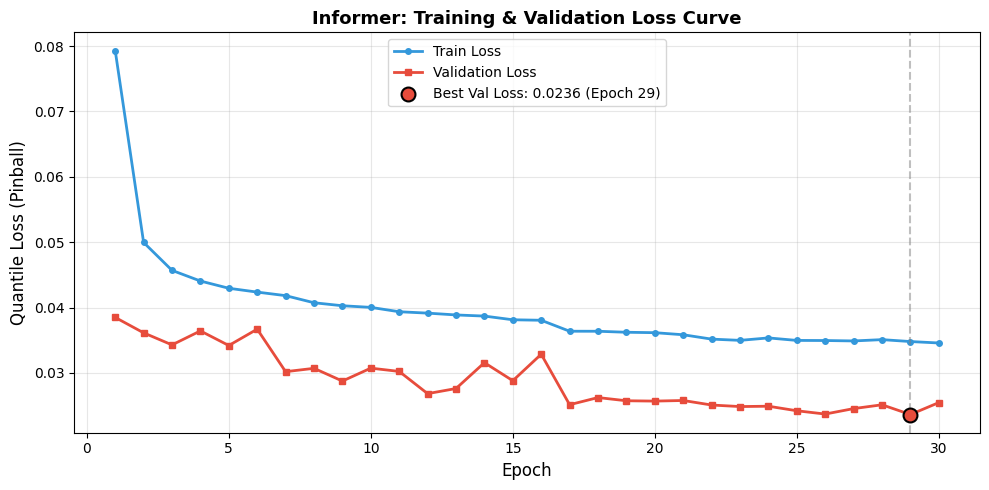

In [6]:
# =========================================================
# INFORMER — TRAINING & VALIDATION LOSS CURVE
# =========================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
epochs = range(1, len(inf_train_losses) + 1)
ax.plot(epochs, inf_train_losses, label='Train Loss', color='#3498db', linewidth=2, marker='o', markersize=4)
ax.plot(epochs, inf_val_losses, label='Validation Loss', color='#e74c3c', linewidth=2, marker='s', markersize=4)

best_epoch = np.argmin(inf_val_losses) + 1
best_val = min(inf_val_losses)
ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5)
ax.scatter([best_epoch], [best_val], color='#e74c3c', s=100, zorder=5,
           edgecolors='black', linewidths=1.5, label=f'Best Val Loss: {best_val:.4f} (Epoch {best_epoch})')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Quantile Loss (Pinball)', fontsize=12)
ax.set_title('Informer: Training & Validation Loss Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()